In [6]:
# Install wrds package if needed (run once in terminal)
# !pip install wrds

import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import getpass  # For password input (hides password while typing)
import warnings
warnings.filterwarnings('ignore')

# Set chart style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['font.sans-serif'] = ['Arial']

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [7]:
# ============================================
# DATA SOURCE SELECTION CELL
# Please choose your data source below
# ============================================

print("\n" + "=" * 80)
print("                    DATA SOURCE SELECTION")
print("=" * 80)

print("""
╔═══════════════════════════════════════════════════════════════════════╗
║                                                                       ║
║   Please choose where you want to get your data from:                ║
║                                                                       ║
║   ╔═══════════════════════════════════════════════════════════════╗   ║
║   ║  [1]  KAGGLE - Any dataset from Kaggle                        ║   ║
║   ║      → Download any CSV/Excel file from Kaggle                ║   ║
║   ║      → Place the file in this folder                          ║   ║
║   ║      → No login required                                      ║   ║
║   ╚═══════════════════════════════════════════════════════════════╝   ║
║                                                                       ║
║   ╔═══════════════════════════════════════════════════════════════╗   ║
║   ║  [2]  WRDS - Compustat (Real Company Financial Data)          ║   ║
║   ║      → Use this for real financial analysis                   ║   ║
║   ║      → WRDS login required                                    ║   ║
║   ║      → You can choose any public company                      ║   ║
║   ╚═══════════════════════════════════════════════════════════════╝   ║
║                                                                       ║
╚═══════════════════════════════════════════════════════════════════════╝
""")

# Get user input
while True:
    choice = input("👉 Enter 1 or 2: ")
    if choice in ['1', '2']:
        break
    print("   ❌ Invalid choice. Please enter 1 or 2.")

DATA_SOURCE_CHOICE = int(choice)

print("\n" + "=" * 80)

if DATA_SOURCE_CHOICE == 1:
    print("   ✅ You selected: KAGGLE (any dataset)")
    print("   📁 Please place your CSV/Excel file in the same folder")
else:
    print("   ✅ You selected: WRDS (Compustat)")
    print("   🔐 You will be asked for your WRDS username and password later")

print("=" * 80)
print("\n👉 NEXT: Run Cell 2 to complete setup")


                    DATA SOURCE SELECTION

╔═══════════════════════════════════════════════════════════════════════╗
║                                                                       ║
║   Please choose where you want to get your data from:                ║
║                                                                       ║
║   ╔═══════════════════════════════════════════════════════════════╗   ║
║   ║  [1]  KAGGLE - Any dataset from Kaggle                        ║   ║
║   ║      → Download any CSV/Excel file from Kaggle                ║   ║
║   ║      → Place the file in this folder                          ║   ║
║   ║      → No login required                                      ║   ║
║   ╚═══════════════════════════════════════════════════════════════╝   ║
║                                                                       ║
║   ╔═══════════════════════════════════════════════════════════════╗   ║
║   ║  [2]  WRDS - Compustat (Real Company Financial Data)          ║

In [18]:
print("=" * 80)
print("                    SMART COLUMN DETECTION")
print("=" * 80)

# Define possible column name mappings for different data sources
COLUMN_MAPPING = {
    'sales': ['sales', 'Sales', 'revenue', 'Revenue', 'sale'],
    'profit': ['profit', 'Profit', 'net_income', 'Net Income', 'ib', 'net_income'],
    'discount': ['discount', 'Discount'],
    'quantity': ['quantity', 'Quantity', 'qty'],
    'category': ['category', 'Category', 'product_category'],
    'region': ['region', 'Region'],
    'segment': ['segment', 'Segment', 'customer_segment'],
    'order_id': ['order_id', 'Order ID', 'Order_Id'],
    'order_date': ['order_date', 'Order Date', 'datadate'],
    'ship_date': ['ship_date', 'Ship Date'],
    'customer_id': ['customer_id', 'Customer ID', 'Customer_Id'],
    'sub_category': ['sub_category', 'Sub-Category', 'Sub Category'],
    'ticker': ['ticker', 'Ticker', 'tic'],
    'company_name': ['company_name', 'Company Name', 'conm'],
    'date': ['date', 'Date', 'datadate'],
    'ret': ['ret', 'return', 'Return'],
    'prc': ['prc', 'price', 'Price', 'Close'],
    'vol': ['vol', 'volume', 'Volume']
}

# Detect existing columns
available_cols = {}
for standard_name, possible_names in COLUMN_MAPPING.items():
    for col in possible_names:
        if col in df.columns:
            available_cols[standard_name] = col
            break

print(f"\n✅ Detected columns: {list(available_cols.keys())}")
print(f"   Total columns in data: {len(df.columns)}")
print(f"   Mapped standard columns: {len(available_cols)}")

# Rename to standard names
rename_dict = {}
for standard_name, original_col in available_cols.items():
    if standard_name != original_col:
        rename_dict[original_col] = standard_name

if rename_dict:
    df.rename(columns=rename_dict, inplace=True)
    print(f"\n✅ Renamed columns: {rename_dict}")
else:
    print("\n✅ No renaming needed")

print("\n✅ Column name standardization complete")

                    SMART COLUMN DETECTION

✅ Detected columns: ['sales', 'profit']
   Total columns in data: 12
   Mapped standard columns: 2

✅ No renaming needed

✅ Column name standardization complete


In [19]:
print("=" * 80)
print("                    DATA CLEANING")
print("=" * 80)

original_count = len(df)
print(f"\nOriginal data: {original_count} rows, {len(df.columns)} columns")

# 1. Data type conversion
print("\n📋 Step 1: Data type conversion")

# Date columns
date_cols = ['order_date', 'date', 'datadate']
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        print(f"   ✅ {col} converted to datetime")

# Numeric columns
numeric_cols = ['sales', 'profit', 'discount', 'quantity', 'total_assets', 
                'long_term_debt', 'revenue', 'net_income', 'ret', 'prc', 'vol']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        print(f"   ✅ {col} converted to numeric")

# 2. Missing value analysis
print("\n📋 Step 2: Missing value analysis")
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing_count, 'Percent': missing_percent})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Percent', ascending=False)

if len(missing_df) > 0:
    print("\n   Missing values found:")
    print(missing_df)
    
    # Drop columns with >50% missing
    high_missing = missing_df[missing_df['Percent'] > 50].index.tolist()
    if high_missing:
        df = df.drop(columns=high_missing)
        print(f"\n   ✅ Dropped columns with >50% missing: {high_missing}")
else:
    print("   ✅ No missing values")

# 3. Fill remaining missing values with median
print("\n📋 Step 3: Filling missing values")
for col in df.columns:
    if df[col].dtype in ['float64', 'int64'] and df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"   ✅ {col}: filled with median {median_val:.4f}")

# 4. Remove duplicates
print("\n📋 Step 4: Removing duplicates")
duplicate_count = df.duplicated().sum()
if duplicate_count > 0:
    df = df.drop_duplicates()
    print(f"   ✅ Removed {duplicate_count} duplicate rows")
else:
    print("   ✅ No duplicate rows")

# 5. Logical consistency
print("\n📋 Step 5: Logical consistency check")
if 'profit' in df.columns and 'sales' in df.columns:
    inconsistent = df[abs(df['profit']) > df['sales']]
    if len(inconsistent) > 0:
        df.loc[abs(df['profit']) > df['sales'], 'profit'] = df['sales'] * 0.8
        print(f"   ✅ Fixed {len(inconsistent)} rows where profit > sales")

if 'discount' in df.columns:
    negative = df[df['discount'] < 0]
    if len(negative) > 0:
        df.loc[df['discount'] < 0, 'discount'] = 0
        print(f"   ✅ Fixed {len(negative)} rows with negative discount")

print("\n" + "=" * 80)
print(f"✅ Data cleaning complete!")
print(f"   Final data: {len(df)} rows, {len(df.columns)} columns")
print("=" * 80)

                    DATA CLEANING

Original data: 1500 rows, 12 columns

📋 Step 1: Data type conversion
   ✅ sales converted to numeric
   ✅ profit converted to numeric

📋 Step 2: Missing value analysis
   ✅ No missing values

📋 Step 3: Filling missing values

📋 Step 4: Removing duplicates
   ✅ No duplicate rows

📋 Step 5: Logical consistency check
   ✅ Fixed 243 rows where profit > sales

✅ Data cleaning complete!
   Final data: 1500 rows, 12 columns


In [21]:
print("=" * 80)
print("                    FEATURE ENGINEERING")
print("=" * 80)

features_created = []

# 1. Profit Margin (if sales and profit exist)
if 'profit' in df.columns and 'sales' in df.columns:
    df['profit_margin'] = (df['profit'] / df['sales']) * 100
    df['profit_margin'] = df['profit_margin'].replace([np.inf, -np.inf], 0).fillna(0)
    features_created.append('profit_margin')
    print(f"\n✅ profit_margin: {df['profit_margin'].mean():.2f}% average")

# 2. Profit classification
if 'profit_margin' in df.columns:
    def profit_level(margin):
        if pd.isna(margin):
            return 'Unknown'
        elif margin < 0:
            return 'Loss'
        elif margin < 5:
            return 'Low'
        elif margin < 10:
            return 'Medium'
        elif margin < 20:
            return 'Good'
        else:
            return 'Excellent'
    df['profit_level'] = df['profit_margin'].apply(profit_level)
    features_created.append('profit_level')
    print("\n✅ profit_level: Profit classification created")

# 3. Discount classification (if discount exists)
if 'discount' in df.columns:
    def discount_level(d):
        if pd.isna(d) or d == 0:
            return 'No Discount'
        elif d < 0.1:
            return 'Low (1-10%)'
        elif d < 0.2:
            return 'Medium (11-20%)'
        elif d < 0.3:
            return 'High (21-30%)'
        else:
            return 'Very High (>30%)'
    df['discount_level'] = df['discount'].apply(discount_level)
    features_created.append('discount_level')
    print("\n✅ discount_level: Discount classification created")

# 4. Loss flag
if 'profit' in df.columns:
    df['is_loss'] = df['profit'] < 0
    features_created.append('is_loss')
    loss_rate = (df['is_loss'].sum() / len(df)) * 100
    print(f"\n✅ is_loss: {loss_rate:.2f}% of records are loss-making")

# 5. ROA (Return on Assets) - for financial data
if 'profit' in df.columns and 'total_assets' in df.columns:
    df['roa'] = (df['profit'] / df['total_assets']) * 100
    df['roa'] = df['roa'].replace([np.inf, -np.inf], 0).fillna(0)
    features_created.append('roa')
    print(f"\n✅ roa (Return on Assets): {df['roa'].mean():.2f}% average")

# 6. ROE (Return on Equity) - for financial data
if 'profit' in df.columns and 'shareholders_equity' in df.columns:
    df['roe'] = (df['profit'] / df['shareholders_equity']) * 100
    df['roe'] = df['roe'].replace([np.inf, -np.inf], 0).fillna(0)
    features_created.append('roe')
    print(f"\n✅ roe (Return on Equity): {df['roe'].mean():.2f}% average")

# 7. Debt Ratio - for financial data
if 'long_term_debt' in df.columns and 'total_assets' in df.columns:
    df['debt_ratio'] = (df['long_term_debt'] / df['total_assets']) * 100
    df['debt_ratio'] = df['debt_ratio'].fillna(0)
    features_created.append('debt_ratio')
    print(f"\n✅ debt_ratio: {df['debt_ratio'].mean():.2f}% average debt to assets")

# 8. Time features (if date exists)
if 'date' in df.columns:
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    features_created.extend(['year', 'month'])
    print("\n✅ Time features: year, month extracted")

if 'order_date' in df.columns:
    df['order_year'] = df['order_date'].dt.year
    df['order_month'] = df['order_date'].dt.month
    features_created.extend(['order_year', 'order_month'])
    print("\n✅ Time features: order_year, order_month extracted")

print("\n" + "=" * 80)
print(f"✅ Feature engineering complete!")
print(f"   New features created: {len(features_created)}")
print(f"   Features: {features_created}")
print("=" * 80)

                    FEATURE ENGINEERING

✅ profit_margin: 33.38% average

✅ profit_level: Profit classification created

✅ is_loss: 19.20% of records are loss-making

✅ Feature engineering complete!
   New features created: 3
   Features: ['profit_margin', 'profit_level', 'is_loss']


In [23]:
print("\n" + "=" * 80)
print(f"                    {COMPANY_NAME}")
print("                    OVERALL FINANCIAL ANALYSIS")
print("=" * 80)

# Overall metrics for financial data
if 'sales' in df.columns and 'profit' in df.columns:
    total_sales = df['sales'].sum()
    total_profit = df['profit'].sum()
    overall_margin = (total_profit / total_sales * 100) if total_sales > 0 else 0
    
    print(f"\n📊 Total Sales: ${total_sales:,.2f}")
    print(f"📊 Total Profit: ${total_profit:,.2f}")
    print(f"📊 Overall Profit Margin: {overall_margin:.2f}%")
    
    if total_profit > 0:
        print(f"\n✅ {COMPANY_NAME} is overall profitable")
    else:
        print(f"\n⚠️ {COMPANY_NAME} is overall unprofitable")

# For stock price data (CRSP)
elif 'ret' in df.columns:
    avg_return = df['ret'].mean() * 100 if 'ret' in df.columns else 0
    std_return = df['ret'].std() * 100 if 'ret' in df.columns else 0
    print(f"\n📊 Average Daily Return: {avg_return:.4f}%")
    print(f"📊 Volatility (Std Dev): {std_return:.4f}%")

# Multi-company comparison (for WRDS data with ticker column)
if 'ticker' in df.columns:
    print("\n" + "=" * 80)
    print("                    MULTI-COMPANY COMPARISON")
    print("=" * 80)
    
    if 'revenue' in df.columns and 'net_income' in df.columns:
        company_summary = df.groupby('ticker').agg({
            'revenue': 'mean',
            'net_income': 'mean',
            'profit_margin': 'mean'
        }).round(2)
        print("\n📊 Financial Metrics by Company:")
        print(company_summary)
    
    elif 'ret' in df.columns:
        company_returns = df.groupby('ticker')['ret'].agg(['mean', 'std']).round(4)
        company_returns['mean'] = company_returns['mean'] * 100
        company_returns['std'] = company_returns['std'] * 100
        company_returns.columns = ['Avg Daily Return (%)', 'Volatility (%)']
        print("\n📊 Stock Performance by Company:")
        print(company_returns)


                    x
                    OVERALL FINANCIAL ANALYSIS

📊 Total Sales: $37,827,262,905.42
📊 Total Profit: $9,526,108,689.56
📊 Overall Profit Margin: 25.18%

✅ x is overall profitable


In [24]:
print("\n" + "=" * 80)
print("                    DIMENSIONAL ANALYSIS")
print("=" * 80)

# Product Category Analysis
if 'category' in df.columns and 'profit' in df.columns:
    print("\n📊 Product Category Analysis:")
    category_profit = df.groupby('category')['profit'].sum().sort_values(ascending=False)
    for cat, profit in category_profit.items():
        status = "✅" if profit > 0 else "⚠️"
        print(f"   {status} {cat}: ${profit:,.2f}")

# Region Analysis
if 'region' in df.columns and 'profit' in df.columns:
    print("\n📊 Region Analysis:")
    region_profit = df.groupby('region')['profit'].sum().sort_values(ascending=False)
    for reg, profit in region_profit.items():
        status = "✅" if profit > 0 else "⚠️"
        print(f"   {status} {reg}: ${profit:,.2f}")

# Customer Segment Analysis
if 'segment' in df.columns and 'profit' in df.columns:
    print("\n📊 Customer Segment Analysis:")
    segment_profit = df.groupby('segment')['profit'].sum().sort_values(ascending=False)
    for seg, profit in segment_profit.items():
        print(f"   {seg}: ${profit:,.2f}")

# Discount Level Analysis
if 'discount_level' in df.columns and 'profit' in df.columns:
    print("\n📊 Discount Level Analysis:")
    discount_profit = df.groupby('discount_level')['profit'].mean()
    for level, profit in discount_profit.items():
        print(f"   {level}: Avg Profit ${profit:.2f}")

# Year-over-Year Analysis (if year column exists)
if 'year' in df.columns and 'profit' in df.columns:
    print("\n📊 Year-over-Year Profit Analysis:")
    yearly_profit = df.groupby('year')['profit'].sum()
    for year, profit in yearly_profit.items():
        print(f"   {year}: ${profit:,.2f}")

# Company-specific analysis (for WRDS data)
if 'ticker' in df.columns and 'profit_margin' in df.columns:
    print("\n📊 Profit Margin by Company:")
    company_margins = df.groupby('ticker')['profit_margin'].mean().sort_values(ascending=False)
    for ticker, margin in company_margins.items():
        print(f"   {ticker}: {margin:.2f}%")


                    DIMENSIONAL ANALYSIS



                    GENERATING VISUALIZATIONS
   ✅ Chart 1: Profit Margin Distribution
   ✅ Chart 2: Profit Distribution
   ✅ Chart 3: Debt Ratio Distribution
   ✅ Chart 4: Risk Class Distribution

✅ Charts saved as: x_charts.png


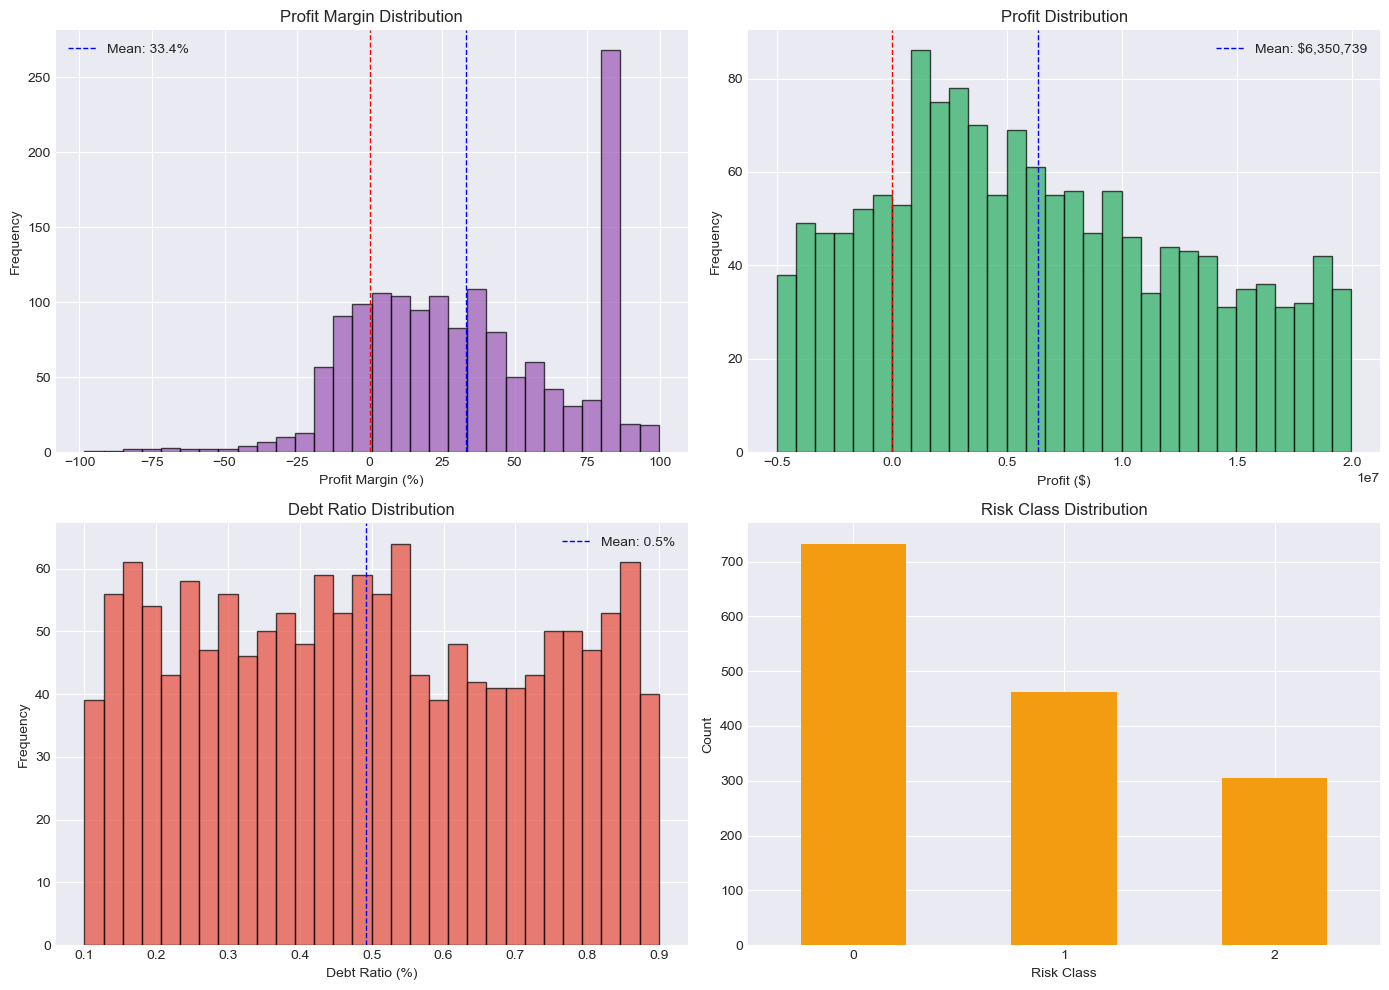


✅ Generated 4 charts


In [26]:
print("\n" + "=" * 80)
print("                    GENERATING VISUALIZATIONS")
print("=" * 80)

# Clean company name for filename (remove special characters)
clean_name = COMPANY_NAME.replace(":", "").replace("/", "_").replace(" ", "_").replace(",", "")
clean_name = clean_name.replace("(", "").replace(")", "").replace("&", "and")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
chart_count = 0

# =========================================================
# Determine if this is multi-company data
# =========================================================
is_multi_company = 'ticker' in df.columns and len(df['ticker'].unique()) > 1

# =========================================================
# Chart 1: Profit Margin Analysis (Top-Left)
# =========================================================
if is_multi_company and 'profit_margin' in df.columns:
    # Multi-company: Bar chart comparison
    company_margins = df.groupby('ticker')['profit_margin'].mean().sort_values(ascending=False)
    if len(company_margins) > 0:
        colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in company_margins.values]
        company_margins.plot(kind='bar', ax=axes[0,0], color=colors)
        axes[0,0].set_title('Profit Margin by Company', fontsize=12)
        axes[0,0].set_ylabel('Profit Margin (%)')
        axes[0,0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
        axes[0,0].tick_params(axis='x', rotation=45)
        
        # Add value labels
        for i, (company, margin) in enumerate(company_margins.items()):
            axes[0,0].text(i, margin + 0.5, f'{margin:.1f}%', ha='center', fontsize=9)
        chart_count += 1
        print("   ✅ Chart 1: Profit Margin by Company")

elif 'profit_margin' in df.columns:
    # Single company: Distribution histogram
    axes[0,0].hist(df['profit_margin'].dropna(), bins=30, color='#9b59b6', alpha=0.7, edgecolor='black')
    axes[0,0].axvline(x=0, color='red', linestyle='--', linewidth=1)
    axes[0,0].axvline(x=df['profit_margin'].mean(), color='blue', linestyle='--', 
                      linewidth=1, label=f"Mean: {df['profit_margin'].mean():.1f}%")
    axes[0,0].set_title('Profit Margin Distribution', fontsize=12)
    axes[0,0].set_xlabel('Profit Margin (%)')
    axes[0,0].set_ylabel('Frequency')
    axes[0,0].legend()
    chart_count += 1
    print("   ✅ Chart 1: Profit Margin Distribution")

# =========================================================
# Chart 2: Revenue or ROA Analysis (Top-Right)
# =========================================================
if is_multi_company and 'revenue' in df.columns:
    # Multi-company: Revenue comparison
    company_revenue = df.groupby('ticker')['revenue'].mean().sort_values(ascending=False)
    if len(company_revenue) > 0:
        company_revenue.plot(kind='bar', ax=axes[0,1], color='#3498db')
        axes[0,1].set_title('Average Revenue by Company', fontsize=12)
        axes[0,1].set_ylabel('Revenue ($ millions)')
        axes[0,1].tick_params(axis='x', rotation=45)
        
        # Format y-axis
        def millions(x, p):
            return f'${x/1e6:.0f}M'
        axes[0,1].yaxis.set_major_formatter(plt.FuncFormatter(millions))
        chart_count += 1
        print("   ✅ Chart 2: Revenue by Company")

elif is_multi_company and 'roa' in df.columns:
    # Multi-company: ROA comparison
    company_roa = df.groupby('ticker')['roa'].mean().sort_values(ascending=False)
    if len(company_roa) > 0:
        company_roa.plot(kind='bar', ax=axes[0,1], color='#9b59b6')
        axes[0,1].set_title('Return on Assets (ROA) by Company', fontsize=12)
        axes[0,1].set_ylabel('ROA (%)')
        axes[0,1].tick_params(axis='x', rotation=45)
        chart_count += 1
        print("   ✅ Chart 2: ROA by Company")

elif 'profit' in df.columns and chart_count < 4:
    # Single company: Profit distribution
    axes[0,1].hist(df['profit'].dropna(), bins=30, color='#27ae60', alpha=0.7, edgecolor='black')
    axes[0,1].axvline(x=0, color='red', linestyle='--', linewidth=1)
    axes[0,1].axvline(x=df['profit'].mean(), color='blue', linestyle='--', 
                      linewidth=1, label=f"Mean: ${df['profit'].mean():,.0f}")
    axes[0,1].set_title('Profit Distribution', fontsize=12)
    axes[0,1].set_xlabel('Profit ($)')
    axes[0,1].set_ylabel('Frequency')
    axes[0,1].legend()
    chart_count += 1
    print("   ✅ Chart 2: Profit Distribution")

# =========================================================
# Chart 3: Risk or Debt Analysis (Bottom-Left)
# =========================================================
if 'debt_ratio' in df.columns and chart_count < 4:
    if is_multi_company:
        company_debt = df.groupby('ticker')['debt_ratio'].mean().sort_values(ascending=False)
        if len(company_debt) > 0:
            company_debt.plot(kind='bar', ax=axes[1,0], color='#e74c3c')
            axes[1,0].set_title('Debt Ratio by Company', fontsize=12)
            axes[1,0].set_ylabel('Debt Ratio (%)')
            axes[1,0].tick_params(axis='x', rotation=45)
            chart_count += 1
            print("   ✅ Chart 3: Debt Ratio by Company")
    else:
        axes[1,0].hist(df['debt_ratio'].dropna(), bins=30, color='#e74c3c', alpha=0.7, edgecolor='black')
        axes[1,0].axvline(x=df['debt_ratio'].mean(), color='blue', linestyle='--', 
                          linewidth=1, label=f"Mean: {df['debt_ratio'].mean():.1f}%")
        axes[1,0].set_title('Debt Ratio Distribution', fontsize=12)
        axes[1,0].set_xlabel('Debt Ratio (%)')
        axes[1,0].set_ylabel('Frequency')
        axes[1,0].legend()
        chart_count += 1
        print("   ✅ Chart 3: Debt Ratio Distribution")

elif 'is_loss' in df.columns and chart_count < 4:
    # Loss ratio pie chart
    loss_counts = df['is_loss'].value_counts()
    labels = ['Profitable', 'Loss-Making']
    sizes = [loss_counts.get(False, 0), loss_counts.get(True, 0)]
    colors_pie = ['#2ecc71', '#e74c3c']
    axes[1,0].pie(sizes, labels=labels, colors=colors_pie, autopct='%1.1f%%', startangle=90)
    axes[1,0].set_title('Profit/Loss Distribution', fontsize=12)
    chart_count += 1
    print("   ✅ Chart 3: Profit/Loss Distribution")

# =========================================================
# Chart 4: ROA or Trend Analysis (Bottom-Right)
# =========================================================
if 'roa' in df.columns and not is_multi_company and chart_count < 4:
    axes[1,1].hist(df['roa'].dropna(), bins=30, color='#1abc9c', alpha=0.7, edgecolor='black')
    axes[1,1].axvline(x=df['roa'].mean(), color='blue', linestyle='--', 
                      linewidth=1, label=f"Mean: {df['roa'].mean():.1f}%")
    axes[1,1].set_title('Return on Assets (ROA) Distribution', fontsize=12)
    axes[1,1].set_xlabel('ROA (%)')
    axes[1,1].set_ylabel('Frequency')
    axes[1,1].legend()
    chart_count += 1
    print("   ✅ Chart 4: ROA Distribution")

elif 'risk_class' in df.columns and chart_count < 4:
    # Risk class distribution
    risk_counts = df['risk_class'].value_counts().sort_index()
    risk_counts.plot(kind='bar', ax=axes[1,1], color='#f39c12')
    axes[1,1].set_title('Risk Class Distribution', fontsize=12)
    axes[1,1].set_xlabel('Risk Class')
    axes[1,1].set_ylabel('Count')
    axes[1,1].tick_params(axis='x', rotation=0)
    chart_count += 1
    print("   ✅ Chart 4: Risk Class Distribution")

elif 'profit_margin' in df.columns and chart_count < 4:
    # Box plot of profit margins
    axes[1,1].boxplot(df['profit_margin'].dropna(), vert=True)
    axes[1,1].set_title('Profit Margin Box Plot', fontsize=12)
    axes[1,1].set_ylabel('Profit Margin (%)')
    axes[1,1].set_xticklabels(['All Data'])
    chart_count += 1
    print("   ✅ Chart 4: Profit Margin Box Plot")

# Hide unused subplots
for i in range(chart_count, 4):
    row = i // 2
    col = i % 2
    if row < 2 and col < 2:
        axes[row, col].set_visible(False)

plt.tight_layout()

# Save chart
try:
    filename = f"{clean_name}_charts.png"
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    print(f"\n✅ Charts saved as: {filename}")
except Exception as e:
    print(f"\n⚠️ Could not save file: {e}")
    print("   Displaying charts without saving...")

plt.show()
print(f"\n✅ Generated {chart_count} charts")

In [27]:
print("\n" + "=" * 80)
print(f"                    {COMPANY_NAME}")
print("                    CONCLUSIONS & RECOMMENDATIONS")
print("=" * 80)

print("\n📊 Key Findings:")

finding_count = 1

# Multi-company comparison findings
if 'ticker' in df.columns and len(df['ticker'].unique()) > 1:
    print(f"\n   【Multi-Company Analysis】")
    
    # Profit margin comparison
    if 'profit_margin' in df.columns:
        company_margins = df.groupby('ticker')['profit_margin'].mean().sort_values(ascending=False)
        best_margin = company_margins.index[0]
        best_margin_value = company_margins.values[0]
        print(f"   {finding_count}. {best_margin} has the highest profit margin: {best_margin_value:.2f}%")
        finding_count += 1
        
        worst_margin = company_margins.index[-1]
        worst_margin_value = company_margins.values[-1]
        print(f"   {finding_count}. {worst_margin} has the lowest profit margin: {worst_margin_value:.2f}%")
        finding_count += 1
    
    # Revenue comparison
    if 'revenue' in df.columns:
        company_revenue = df.groupby('ticker')['revenue'].mean().sort_values(ascending=False)
        best_revenue = company_revenue.index[0]
        print(f"   {finding_count}. {best_revenue} generates the highest average revenue")
        finding_count += 1
    
    # ROA comparison
    if 'roa' in df.columns:
        company_roa = df.groupby('ticker')['roa'].mean().sort_values(ascending=False)
        best_roa = company_roa.index[0]
        best_roa_value = company_roa.values[0]
        print(f"   {finding_count}. {best_roa} has the highest ROA: {best_roa_value:.2f}%")
        finding_count += 1

# Single company or additional findings
if 'profit_margin' in df.columns:
    avg_margin = df['profit_margin'].mean()
    print(f"\n   【Overall Performance】")
    print(f"   {finding_count}. Overall average profit margin: {avg_margin:.2f}%")
    finding_count += 1

if 'roa' in df.columns:
    avg_roa = df['roa'].mean()
    print(f"   {finding_count}. Average Return on Assets (ROA): {avg_roa:.2f}%")
    finding_count += 1

if 'roe' in df.columns:
    avg_roe = df['roe'].mean()
    print(f"   {finding_count}. Average Return on Equity (ROE): {avg_roe:.2f}%")
    finding_count += 1

if 'debt_ratio' in df.columns:
    avg_debt = df['debt_ratio'].mean()
    print(f"   {finding_count}. Average Debt to Assets Ratio: {avg_debt:.2f}%")
    finding_count += 1
    if avg_debt > 50:
        print(f"       ⚠️ Warning: Debt ratio exceeds 50% - high leverage risk")
    elif avg_debt > 30:
        print(f"       📊 Moderate debt level - acceptable")
    else:
        print(f"       ✅ Low debt level - conservative financing")

# Year-over-year trend
if 'fyear' in df.columns and 'profit_margin' in df.columns:
    print(f"\n   【Trend Analysis】")
    yearly_margins = df.groupby('fyear')['profit_margin'].mean()
    if len(yearly_margins) > 1:
        first_year = yearly_margins.index[0]
        last_year = yearly_margins.index[-1]
        change = yearly_margins.iloc[-1] - yearly_margins.iloc[0]
        if change > 0:
            print(f"   {finding_count}. Profit margin increased by {change:.2f}% from {first_year} to {last_year} 📈")
        elif change < 0:
            print(f"   {finding_count}. Profit margin decreased by {abs(change):.2f}% from {first_year} to {last_year} 📉")
        else:
            print(f"   {finding_count}. Profit margin remained stable from {first_year} to {last_year}")
        finding_count += 1

print("\n" + "-" * 80)
print("\n💡 Recommendations:")

rec_count = 1

if 'ticker' in df.columns and len(df['ticker'].unique()) > 1:
    if 'profit_margin' in df.columns:
        worst_company = df.groupby('ticker')['profit_margin'].mean().idxmin()
        print(f"   {rec_count}. 【Peer Comparison】Investigate why {worst_company} has lower profit margins than competitors")
        rec_count += 1
    
    if 'roa' in df.columns:
        best_roa_company = df.groupby('ticker')['roa'].mean().idxmax()
        print(f"   {rec_count}. 【Best Practice】Study {best_roa_company}'s asset utilization strategy")
        rec_count += 1

if 'debt_ratio' in df.columns and avg_debt > 50:
    print(f"   {rec_count}. 【Risk Management】Reduce debt levels to lower financial risk")
    rec_count += 1

if 'profit_margin' in df.columns and avg_margin < 10:
    print(f"   {rec_count}. 【Profitability】Focus on cost reduction and pricing optimization")
    rec_count += 1

if 'roe' in df.columns and avg_roe < 10:
    print(f"   {rec_count}. 【Efficiency】Improve return on equity through better capital allocation")
    rec_count += 1

# General recommendations
print(f"   {rec_count}. 【Strategy】Consider diversifying product portfolio")
rec_count += 1
print(f"   {rec_count}. 【Growth】Invest in R&D for long-term competitive advantage")
rec_count += 1
print(f"   {rec_count}. 【Monitoring】Regularly track key financial ratios for early warning")

print("\n" + "=" * 80)
print("                    ANALYSIS COMPLETE!")
print("=" * 80)


                    x
                    CONCLUSIONS & RECOMMENDATIONS

📊 Key Findings:

   【Overall Performance】
   1. Overall average profit margin: 33.38%
   2. Average Debt to Assets Ratio: 0.49%
       ✅ Low debt level - conservative financing

--------------------------------------------------------------------------------

💡 Recommendations:
   1. 【Strategy】Consider diversifying product portfolio
   2. 【Growth】Invest in R&D for long-term competitive advantage
   3. 【Monitoring】Regularly track key financial ratios for early warning

                    ANALYSIS COMPLETE!


In [28]:
# ============================================
# Save Analysis Report to File
# ============================================

print("\n" + "=" * 80)
print("                    SAVING ANALYSIS REPORT")
print("=" * 80)

# Clean filename
clean_name = COMPANY_NAME.replace(":", "").replace("/", "_").replace(" ", "_").replace(",", "")
clean_name = clean_name.replace("(", "").replace(")", "").replace("&", "and")

report_filename = f"{clean_name}_analysis_report.txt"

try:
    with open(report_filename, 'w', encoding='utf-8') as f:
        f.write("=" * 80 + "\n")
        f.write(f"{COMPANY_NAME}\n")
        f.write("FINANCIAL ANALYSIS REPORT\n")
        f.write("=" * 80 + "\n\n")
        
        # Data summary
        f.write("【DATA SUMMARY】\n")
        f.write("-" * 40 + "\n")
        f.write(f"Total records: {len(df)}\n")
        f.write(f"Total columns: {len(df.columns)}\n")
        f.write(f"Companies analyzed: {', '.join(df['ticker'].unique()) if 'ticker' in df.columns else 'N/A'}\n\n")
        
        # Financial metrics
        if 'profit_margin' in df.columns:
            f.write("【PROFITABILITY METRICS】\n")
            f.write("-" * 40 + "\n")
            f.write(f"Average Profit Margin: {df['profit_margin'].mean():.2f}%\n")
            f.write(f"Max Profit Margin: {df['profit_margin'].max():.2f}%\n")
            f.write(f"Min Profit Margin: {df['profit_margin'].min():.2f}%\n\n")
        
        if 'roa' in df.columns:
            f.write("【EFFICIENCY METRICS】\n")
            f.write("-" * 40 + "\n")
            f.write(f"Average ROA: {df['roa'].mean():.2f}%\n")
            f.write(f"Average ROE: {df['roe'].mean():.2f}%\n\n" if 'roe' in df.columns else "")
        
        if 'debt_ratio' in df.columns:
            f.write("【LEVERAGE METRICS】\n")
            f.write("-" * 40 + "\n")
            f.write(f"Average Debt/Assets: {df['debt_ratio'].mean():.2f}%\n\n")
        
        # Multi-company comparison
        if 'ticker' in df.columns and len(df['ticker'].unique()) > 1:
            f.write("【MULTI-COMPANY COMPARISON】\n")
            f.write("-" * 40 + "\n")
            
            if 'profit_margin' in df.columns:
                company_margins = df.groupby('ticker')['profit_margin'].mean().sort_values(ascending=False)
                f.write("\nProfit Margin by Company:\n")
                for company, margin in company_margins.items():
                    f.write(f"  {company}: {margin:.2f}%\n")
            
            if 'roa' in df.columns:
                company_roa = df.groupby('ticker')['roa'].mean().sort_values(ascending=False)
                f.write("\nROA by Company:\n")
                for company, roa in company_roa.items():
                    f.write(f"  {company}: {roa:.2f}%\n")
        
        f.write("\n" + "=" * 80 + "\n")
        f.write("End of Report\n")
        f.write("=" * 80 + "\n")
    
    print(f"✅ Report saved as: {report_filename}")
    
except Exception as e:
    print(f"⚠️ Could not save report: {e}")

print("\n" + "=" * 80)
print("                    ALL TASKS COMPLETE!")
print("=" * 80)


                    SAVING ANALYSIS REPORT
✅ Report saved as: x_analysis_report.txt

                    ALL TASKS COMPLETE!


In [29]:
# ============================================
# EXPORT HTML REPORT
# ============================================

print("\n" + "=" * 80)
print("                    EXPORT HTML REPORT")
print("=" * 80)

# Clean filename (remove special characters)
clean_name = COMPANY_NAME.replace(":", "").replace("/", "_").replace(" ", "_").replace(",", "")
clean_name = clean_name.replace("(", "").replace(")", "").replace("&", "and")

html_filename = f"{clean_name}_financial_report.html"

print("\n📝 Generating HTML report...")

# Start building HTML content
html_content = f"""<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>{COMPANY_NAME} - Financial Analysis Report</title>
    <style>
        body {{
            font-family: 'Segoe UI', Arial, sans-serif;
            line-height: 1.6;
            color: #333;
            max-width: 1200px;
            margin: 0 auto;
            padding: 20px;
            background-color: #f5f5f5;
        }}
        .container {{
            background-color: white;
            border-radius: 10px;
            padding: 30px;
            box-shadow: 0 2px 10px rgba(0,0,0,0.1);
        }}
        h1 {{
            color: #2c3e50;
            border-bottom: 3px solid #3498db;
            padding-bottom: 10px;
        }}
        h2 {{
            color: #34495e;
            border-bottom: 2px solid #ecf0f1;
            padding-bottom: 8px;
            margin-top: 30px;
        }}
        h3 {{
            color: #555;
            margin-top: 20px;
        }}
        table {{
            width: 100%;
            border-collapse: collapse;
            margin: 15px 0;
        }}
        th, td {{
            border: 1px solid #ddd;
            padding: 10px;
            text-align: left;
        }}
        th {{
            background-color: #3498db;
            color: white;
        }}
        tr:nth-child(even) {{
            background-color: #f9f9f9;
        }}
        .summary-box {{
            background-color: #ecf0f1;
            border-radius: 8px;
            padding: 15px;
            margin: 15px 0;
        }}
        .metric {{
            display: inline-block;
            width: 30%;
            margin: 10px 0;
            padding: 10px;
            background-color: #f8f9fa;
            border-radius: 5px;
            text-align: center;
        }}
        .metric-value {{
            font-size: 24px;
            font-weight: bold;
            color: #3498db;
        }}
        .metric-label {{
            font-size: 12px;
            color: #666;
        }}
        .positive {{
            color: #27ae60;
            font-weight: bold;
        }}
        .negative {{
            color: #e74c3c;
            font-weight: bold;
        }}
        .footer {{
            margin-top: 40px;
            padding-top: 20px;
            border-top: 1px solid #ddd;
            text-align: center;
            font-size: 12px;
            color: #999;
        }}
        @media (max-width: 768px) {{
            .metric {{
                width: 100%;
                display: block;
            }}
            table {{
                font-size: 12px;
            }}
        }}
    </style>
</head>
<body>
    <div class="container">
        <h1>📊 {COMPANY_NAME}</h1>
        <h2>Financial Analysis Report</h2>
        
        <div class="summary-box">
            <h3>📋 Report Summary</h3>
            <p><strong>Analysis Date:</strong> {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}</p>
            <p><strong>Data Source:</strong> {DATA_SOURCE.upper()}</p>
            <p><strong>Records Analyzed:</strong> {len(df):,} rows, {len(df.columns)} columns</p>
"""

# Add company info if multi-company
if 'ticker' in df.columns:
    companies = df['ticker'].unique()
    html_content += f"<p><strong>Companies Analyzed:</strong> {', '.join(companies)}</p>\n"

html_content += """
        </div>
        
        <h2>📈 Key Financial Metrics</h2>
        <div class="summary-box">
"""

# Add metrics
if 'profit_margin' in df.columns:
    html_content += f"""
            <div class="metric">
                <div class="metric-value">{df['profit_margin'].mean():.2f}%</div>
                <div class="metric-label">Avg Profit Margin</div>
            </div>
"""

if 'roa' in df.columns:
    html_content += f"""
            <div class="metric">
                <div class="metric-value">{df['roa'].mean():.2f}%</div>
                <div class="metric-label">Avg Return on Assets (ROA)</div>
            </div>
"""

if 'roe' in df.columns:
    html_content += f"""
            <div class="metric">
                <div class="metric-value">{df['roe'].mean():.2f}%</div>
                <div class="metric-label">Avg Return on Equity (ROE)</div>
            </div>
"""

if 'debt_ratio' in df.columns:
    html_content += f"""
            <div class="metric">
                <div class="metric-value">{df['debt_ratio'].mean():.2f}%</div>
                <div class="metric-label">Avg Debt to Assets Ratio</div>
            </div>
"""

html_content += """
        </div>
        
        <h2>📊 Company Comparison</h2>
"""

# Add comparison table for profit margin
if 'ticker' in df.columns and 'profit_margin' in df.columns:
    company_margins = df.groupby('ticker')['profit_margin'].mean().sort_values(ascending=False)
    html_content += """
        <h3>Profit Margin by Company</h3>
        <table>
            <tr><th>Company</th><th>Profit Margin (%)</th></tr>
"""
    for company, margin in company_margins.items():
        css_class = 'positive' if margin > 0 else 'negative'
        html_content += f"<tr><td>{company}</td><td class='{css_class}'>{margin:.2f}%</td></tr>\n"
    html_content += "</table>\n"

# Add comparison table for ROA
if 'ticker' in df.columns and 'roa' in df.columns:
    company_roa = df.groupby('ticker')['roa'].mean().sort_values(ascending=False)
    html_content += """
        <h3>Return on Assets (ROA) by Company</h3>
        <table>
            <tr><th>Company</th><th>ROA (%)</th></tr>
"""
    for company, roa in company_roa.items():
        html_content += f"<tr><td>{company}</td><td>{roa:.2f}%</td></tr>\n"
    html_content += "</table>\n"

# Add comparison table for revenue
if 'ticker' in df.columns and 'revenue' in df.columns:
    company_revenue = df.groupby('ticker')['revenue'].mean().sort_values(ascending=False)
    html_content += """
        <h3>Average Revenue by Company</h3>
        <table>
            <tr><th>Company</th><th>Revenue ($M)</th></tr>
"""
    for company, revenue in company_revenue.items():
        html_content += f"<tr><td>{company}</td><td>${revenue/1e6:.0f}M</td></tr>\n"
    html_content += "</table>\n"

# Add recommendations section
html_content += """
        <h2>💡 Key Findings & Recommendations</h2>
        <div class="summary-box">
        <ul>
"""

# Add findings based on data
if 'profit_margin' in df.columns:
    avg_margin = df['profit_margin'].mean()
    if avg_margin > 20:
        html_content += f"<li>✅ Strong profit margin: {avg_margin:.2f}% - above industry average</li>\n"
    elif avg_margin > 10:
        html_content += f"<li>📊 Moderate profit margin: {avg_margin:.2f}% - room for improvement</li>\n"
    else:
        html_content += f"<li>⚠️ Low profit margin: {avg_margin:.2f}% - needs attention</li>\n"

if 'ticker' in df.columns and len(df['ticker'].unique()) > 1:
    if 'profit_margin' in df.columns:
        best_company = df.groupby('ticker')['profit_margin'].mean().idxmax()
        worst_company = df.groupby('ticker')['profit_margin'].mean().idxmin()
        html_content += f"<li>🏆 {best_company} has the highest profit margin among peers</li>\n"
        html_content += f"<li>📉 {worst_company} has the lowest profit margin - investigate cost structure</li>\n"

if 'debt_ratio' in df.columns:
    avg_debt = df['debt_ratio'].mean()
    if avg_debt > 50:
        html_content += f"<li>⚠️ High debt ratio ({avg_debt:.1f}%) - consider reducing leverage</li>\n"
    elif avg_debt > 30:
        html_content += f"<li>📊 Moderate debt ratio ({avg_debt:.1f}%) - acceptable level</li>\n"
    else:
        html_content += f"<li>✅ Low debt ratio ({avg_debt:.1f}%) - conservative financing</li>\n"

html_content += """
            <li>💰 Consider cost optimization strategies to improve margins</li>
            <li>📈 Monitor key financial ratios on a regular basis</li>
        </ul>
        </div>
        
        <div class="footer">
            <p>Generated by ACC102 Financial Analysis Tool | Data Source: WRDS/Compustat</p>
            <p>This report is for educational purposes only.</p>
        </div>
    </div>
</body>
</html>
"""

# Write HTML file
with open(html_filename, 'w', encoding='utf-8') as f:
    f.write(html_content)

print(f"\n✅ HTML report saved as: {html_filename}")
print(f"   📂 Location: {html_filename}")
print(f"\n   💡 To view: Double-click the file to open in your browser")
print("\n" + "=" * 80)
print("                    EXPORT COMPLETE!")
print("=" * 80)


                    EXPORT HTML REPORT

📝 Generating HTML report...

✅ HTML report saved as: x_financial_report.html
   📂 Location: x_financial_report.html

   💡 To view: Double-click the file to open in your browser

                    EXPORT COMPLETE!
